In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/marketing-ab-testing/marketing_AB.csv


                            ''' Markrting A/B Testing/ Bucket Testing / Split Testing ''' 

### In A/B Testing the data is splited into Control group and experimental/Test group.

 - Control Group: They were just exposed to the ad
 - Experimental Group : They know about the ad by psa(public service announcement) or not known of the ad

### Data dictionary:

- Index: Row indexuser
- id: User ID (unique)
- test group: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
- converted: If a person bought the product then True, else is False
- total ads: Amount of ads seen by person
- most ads day: Day that the person saw the biggest amount of ads
- most ads hour: Hour of day that the person saw the biggest amount of ads


# Ultimate goal of the Marketing A/B Testing:
- How the ads are more influencing the customers that inclines to the success?
- Did the ads really influence customers to convert?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, pearsonr, spearmanr
import os
data = pd.read_csv("/kaggle/input/marketing-ab-testing/marketing_AB.csv")
data = data.drop(['Unnamed: 0','user id'], axis = 1, inplace = False)
print(data.head())

  test group  converted  total ads most ads day  most ads hour
0         ad      False        130       Monday             20
1         ad      False         93      Tuesday             22
2         ad      False         21      Tuesday             18
3         ad      False        355      Tuesday             10
4         ad      False        276       Friday             14


In [3]:
data.columns = data.columns.str.replace(" ","_", regex = True)
columns = list(data.columns)
print(columns)

['test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']


In [4]:
for col in columns:
    print(data[col].value_counts())
    print("\n")
  

test_group
ad     564577
psa     23524
Name: count, dtype: int64


converted
False    573258
True      14843
Name: count, dtype: int64


total_ads
1       56606
2       39827
5       29303
3       28661
4       23426
        ...  
1302        1
1035        1
716         1
1014        1
729         1
Name: count, Length: 807, dtype: int64


most_ads_day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64


most_ads_hour
13    47655
12    47298
11    46210
14    45648
15    44683
10    38939
16    37567
17    34988
18    32323
9     31004
19    30352
21    29976
20    28923
22    26432
23    20166
8     17627
7      6405
0      5536
2      5333
1      4802
3      2679
6      2068
5       765
4       722
Name: count, dtype: int64




In [5]:
print(data.describe(), "\n",data.isnull().sum())

           total_ads  most_ads_hour
count  588101.000000  588101.000000
mean       24.820876      14.469061
std        43.715181       4.834634
min         1.000000       0.000000
25%         4.000000      11.000000
50%        13.000000      14.000000
75%        27.000000      18.000000
max      2065.000000      23.000000 
 test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64


In [6]:
print(data['test_group'].value_counts())

print(data['test_group'].value_counts(normalize = True))

print(data.groupby('test_group')['converted'].mean())

test_group
ad     564577
psa     23524
Name: count, dtype: int64
test_group
ad     0.96
psa    0.04
Name: proportion, dtype: float64
test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


## From the above findings , it is evident that The conversion rate for the ad is more which is 96% and the conversion rate for the psa is only 4%. 
- People are more responding to the ad rather than the psa
- I can also sense there is an imbalance in the dataset whixh is irrationla while comparision
- Still need some statistical inference

# Two sample T-test

 ### There are three assumptions that we can make regarding the data groups:

- Whether the two samples data groups are independent.
- Whether the data elements in respective groups follow any normal distribution.
- Whether the given two samples have similar variances. This assumption is also known as the homogeneity assumption.

In [7]:
# cretaing the data groups 
psa_group = data[data['test_group']=='psa']['converted']
ad_group = data[data['test_group']=='ad']['converted']

Null hypothesis(H0):  There is no significant difference between the conversion rate of the ad group and psa group

ALternative Hypothesis(H1): The rate of cioonversion of ad is more significant than the conversion rate of psa group.

In [8]:
# Perform T-test
print(np.var(psa_group),np.var(ad_group))

0.017535337327551324 0.024893932927413112


## t-statistic (t_stat)

- What it measures: How many standard errors the difference between two sample means is away from zero.


- Interpretation: A larger absolute t-stat (positive or negative) typically means a bigger difference relative to the overall variability. The sign of the t-stat tells you which mean is higher (if ad_group is higher on average than psa_group, you’ll see a positive t-stat under a “greater” alternative).

-  The t-statistic tells you how ‘large’ or ‘extreme’ the difference is compared to the variability, and the p-value tells you the likelihood of seeing such a difference if, in reality, there is no difference between the two groups (i.e., under the null hypothesis). If that likelihood (p-value) is very small, you have stronger evidence that a real difference exists.









In [9]:
# As there is no equal propotion. It has False vale for qequal _variance
t_value, p_value = ttest_ind( ad_group,psa_group, alternative = 'greater', equal_var = False)
print(t_value, p_value)

8.657162314551677 2.55380379937953e-18


- From the above reuslts I can interpret that the t_value indicates that there is a lot variance between the two groups.
- P_ value is less 0.05 which indicates that. we can reject the null hypothesis.
- The positive t statistics gives you that the ad group has greater significant conversion compared to the psa group.

## Bootstrapping :
Bootstrapping is a resampling technique used to estimate the sampling distribution of a statistic by repeatedly sampling with replacement from the original dataset.

      means
0  0.025814
1  0.025649
2  0.025639
3  0.025672
4  0.025835
      means
0  0.018449
1  0.019342
2  0.019512
3  0.017684
4  0.019342

T-Test Results:
T-Statistic: 271.1383
P-Value: 0.0000e+00


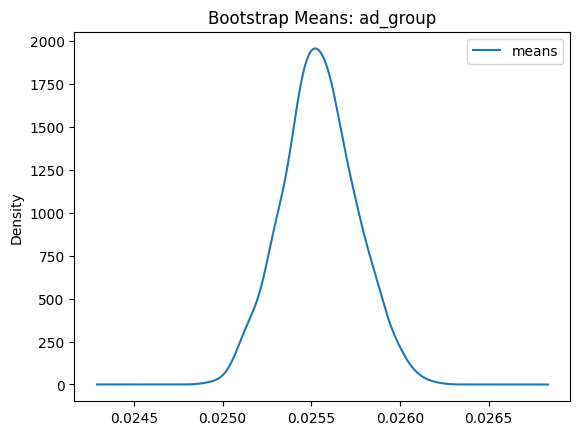

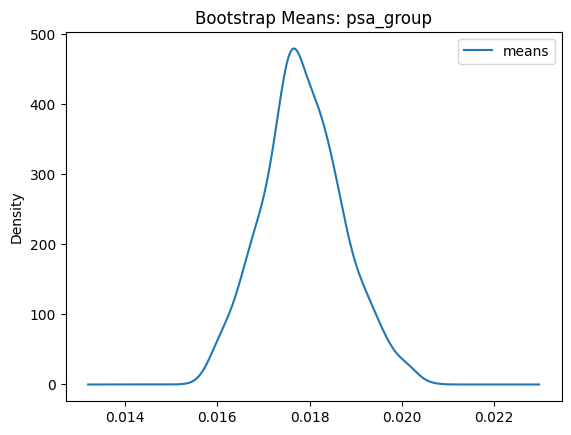

In [10]:
def bootstrap_sample(psa_group, ad_group, length):
    boot_ad = []
    boot_psa = []
    for i in range(length):
        boot_mean_ad = ad_group.sample(frac=1, replace=True).mean()
        boot_ad.append(boot_mean_ad)

        boot_mean_psa = psa_group.sample(frac=1, replace=True).mean()
        boot_psa.append(boot_mean_psa)

    boot_ad_df = pd.DataFrame(boot_ad, columns=['means'])
    boot_psa_df = pd.DataFrame(boot_psa, columns=['means'])
    boot_ad_df.plot(kind='density', title='Bootstrap Means: ad_group')
    boot_psa_df.plot(kind='density', title='Bootstrap Means: psa_group')

    return boot_ad_df, boot_psa_df



boot_ad_df, boot_psa_df = bootstrap_sample(psa_group, ad_group, length=1000)
print(boot_ad_df.head())
print(boot_psa_df.head())

# Perform T-Test 
t_stat, p_value = ttest_ind(
    boot_ad_df['means'],
    boot_psa_df['means'],
    alternative='greater',
    equal_var=False
)

print("\nT-Test Results:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")


From the density plot it seems to be normally distributed both the psa and ad group.

## Chi-Squared test¶
The Chi-Squared test evaluates the independence of two categorical variables.

- Variable 1: converted (whether a user converted or not),
- Variable 2: test_group
  
Null Hypothesis (H0): There is no association between the conversion status and the test group.

Contingency Table: It is matrix format table taht displays teh multivaraite frequency distribution of the variables.


In [11]:
Contingency_table = pd.crosstab(data['converted'],data['test_group'])
Contingency_table

test_group,ad,psa
converted,,
False,550154,23104
True,14423,420


In [12]:
# Perform Chi-Squared Test
chi2, p_chi2, dof, expected = chi2_contingency(Contingency_table)

print("\nChi-Squared Test Results - Test group:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-Value: {p_chi2:.4e}")
print(f"Degrees of Freedom: {dof}")

# Let's check the correlation between day of the week and conversion
contingency_table = pd.crosstab(data[data['test_group']=='ad']['converted'], data[data['test_group']=='ad']['most_ads_day'])

# Perform Chi-Squared Test
chi2, p_chi2, dof, expected = chi2_contingency(Contingency_table)

print("\nChi-Squared Test Results - Day:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-Value: {p_chi2:.4e}")
print(f"Degrees of Freedom: {dof}")


Chi-Squared Test Results - Test group:
Chi2 Statistic: 54.0058
P-Value: 1.9990e-13
Degrees of Freedom: 1

Chi-Squared Test Results - Day:
Chi2 Statistic: 54.0058
P-Value: 1.9990e-13
Degrees of Freedom: 1


## Visualization

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


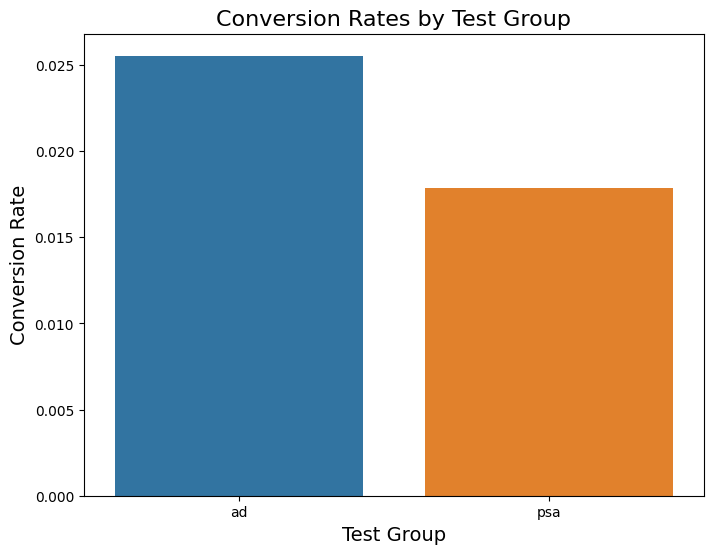

In [13]:
# Conversion rate by test_group
import seaborn as sns
ad_df =data[data['test_group']=='ad']
plt.figure(figsize=(8, 6))
sns.barplot(x=['ad','psa'], y=[ad_group.mean(), psa_group.mean()])
plt.title('Conversion Rates by Test Group', fontsize=16)
plt.xlabel('Test Group', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=14)
plt.show() 

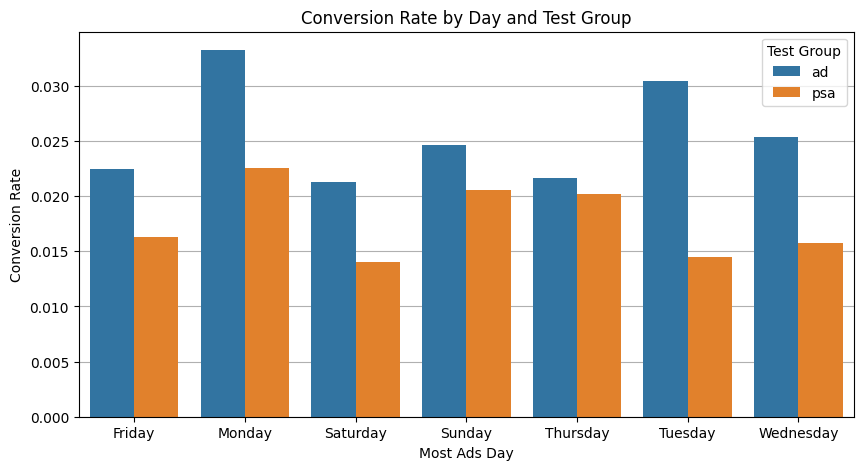

In [14]:
# Conversion rate of test_group converted per day
conversionRateByDay = data.groupby(['most_ads_day', 'test_group'])['converted'].mean()

df_plot = conversionRateByDay.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='most_ads_day', y='converted', hue='test_group',data=df_plot)
plt.xlabel('Most Ads Day')
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Day and Test Group')
plt.legend(title='Test Group')
plt.grid(which='major',axis='y')
plt.gca().set_axisbelow(True) 

plt.show()

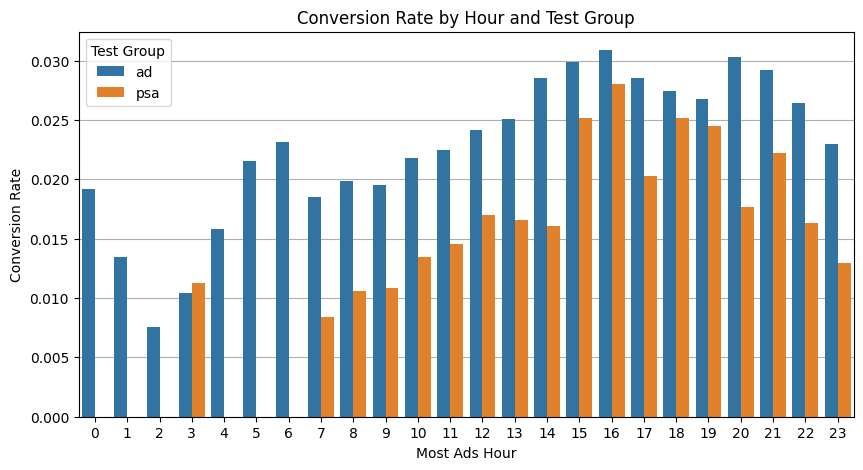

In [15]:
# Conversion rate of test_group converted per hour
conversionRateByHour = data.groupby(['most_ads_hour', 'test_group'])['converted'].mean()

df_plot = conversionRateByHour.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='most_ads_hour', y='converted', hue='test_group',data=df_plot)
plt.xlabel('Most Ads Hour')
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Hour and Test Group')
plt.legend(title='Test Group')
plt.grid(which='major',axis='y')
plt.gca().set_axisbelow(True) 

plt.show()